# Channel Validate 教程

这份 notebook 是当前目录的“模板 / 接口教程”，只针对这两个入口：

- `channel_validate.py`
- `channel_validate_sweep.py`

目标分三步：

1. 先理解最小模板怎么组织参数和刺激。
2. 再运行第一个模板 `channel_validate.py`。
3. 最后使用第二个模板 `channel_validate_sweep.py` 做批量 sweep。

如果你想看“尽量少用函数包装、从零一步一步搭模型”的版本，请看：

- `step_by_step.ipynb`

这份 notebook 不再沿用旧教程流程，只跟当前接口保持一致。


## 0. 准备

运行本 notebook 前，先确认：

- 当前目录里有 `mods/` 目录，示例机制文件是 `mods/kv.mod`
- 如需运行 NEURON 部分，已经在 `mods/` 目录执行过 `nrnivmodl`
- notebook kernel 指向可用的 `braincell` 环境

下面这个单元会把当前工作目录视为 `mod_validate`，并动态加载两个脚本模块。


In [1]:
import importlib.util
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (8, 4)

ROOT = Path.cwd().resolve()
MODS_DIR = ROOT / 'mods'
if not MODS_DIR.is_dir():
    raise FileNotFoundError('请从包含 mods/ 目录的 mod_validate 目录启动或运行本 notebook。')


def load_local_module(module_name: str, path: Path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


single = load_local_module('channel_validate', ROOT / 'channel_validate.py')
sweep = load_local_module('channel_validate_sweep', ROOT / 'channel_validate_sweep.py')
config_path = ROOT / 'channel_validate_sweep.example.json'

ROOT


PosixPath('/home/swl/braincell/examples/convert_mod/mod_validate')

In [2]:
print('当前目录:', ROOT)
print('mods directory exists:', MODS_DIR.is_dir())
print('mods/kv.mod exists:', (MODS_DIR / 'kv.mod').exists())
print('channel_validate.py exists:', (ROOT / 'channel_validate.py').exists())
print('channel_validate_sweep.py exists:', (ROOT / 'channel_validate_sweep.py').exists())
print('example config exists:', config_path.exists())

print('如果还没编译 mod，请先在终端执行:')
print(f'cd {MODS_DIR} && nrnivmodl')


当前目录: /home/swl/braincell/examples/convert_mod/mod_validate
mods directory exists: True
mods/kv.mod exists: True
channel_validate.py exists: True
channel_validate_sweep.py exists: True
example config exists: True
如果还没编译 mod，请先在终端执行:
cd /home/swl/braincell/examples/convert_mod/mod_validate/mods && nrnivmodl


## 1. 最简单的手写方式

这一层不走 JSON 配置，直接在 notebook 里手写：

- `common_params`：共享的几何、膜参数、时间步长
- `ion_spec`：共享的离子类型和反转电位
- `channel_spec`：NEURON / braincell 的通道名，以及一组共享参数
- `leak_spec`：可选 leak
- `I_ext(t_ms)`：任意 Python 电流函数

这个方式最自由，也最适合快速试一个通道。


In [3]:
common_params = {
    'dt_ms': 0.025,
    'tstop_ms': 100.0,
    'v_init_mV': -65.0,
    'temperature_celsius': 25.0,
    'L_um': 10.0,
    'diam_um': 100.0 / np.pi,
    'cm_uF_cm2': 1.0,
}

ion_spec = {
    'ion_type': 'k',
    'ion_rev_mV': -80.0,
}

channel_spec = {
    'mechanism': 'Kv',
    'channel_name': 'IK_Kv_test',
    'params': {
        'gbar': 0.01,
        'v12': 25.0,
        'q': 9.0,
    },
}

leak_spec = {
    'g_S_cm2': 1e-4,
    'e_mV': -65.0,
}


def I_ext(t_ms: float) -> float:
    return 0.01 if 10.0 <= t_ms < 60.0 else 0.0


common_params, ion_spec, channel_spec, leak_spec


({'dt_ms': 0.025,
  'tstop_ms': 100.0,
  'v_init_mV': -65.0,
  'temperature_celsius': 25.0,
  'L_um': 10.0,
  'diam_um': 31.830988618379067,
  'cm_uF_cm2': 1.0},
 {'ion_type': 'k', 'ion_rev_mV': -80.0},
 {'mechanism': 'Kv',
  'channel_name': 'IK_Kv_test',
  'params': {'gbar': 0.01, 'v12': 25.0, 'q': 9.0}},
 {'g_S_cm2': 0.0001, 'e_mV': -65.0})

In [4]:
neuron_cell = single.create_cell_neuron(
    common_params,
    ion_spec,
    channel_spec,
    leak_spec=leak_spec,
    mod_dir=MODS_DIR,
)

braincell_cell = single.create_cell_braincell(
    common_params,
    ion_spec,
    channel_spec,
    leak_spec=leak_spec,
    solver='rk4',
)

t_neuron, i_neuron, v_neuron = single.run_neuron(
    neuron_cell,
    I_ext,
    dt_ms=common_params['dt_ms'],
    tstop_ms=common_params['tstop_ms'],
    v_init_mV=common_params['v_init_mV'],
    temperature_celsius=common_params['temperature_celsius'],
)

t_braincell, i_braincell, v_braincell = single.run_braincell(
    braincell_cell,
    I_ext,
    dt_ms=common_params['dt_ms'],
    tstop_ms=common_params['tstop_ms'],
)

metrics = single.compute_error_metrics(v_neuron, v_braincell)
metrics


--No graphics will be displayed.
ERROR:2026-04-12 12:50:05,134:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.


{'mae': 0.002212983863727814,
 'rmse': 0.002664386061077707,
 'max_abs': 0.004550098293577776,
 'mean_bias': -7.898268202853842e-05,
 'rel_mae_pct': 0.0036926907893904837,
 'n_samples': 4000}

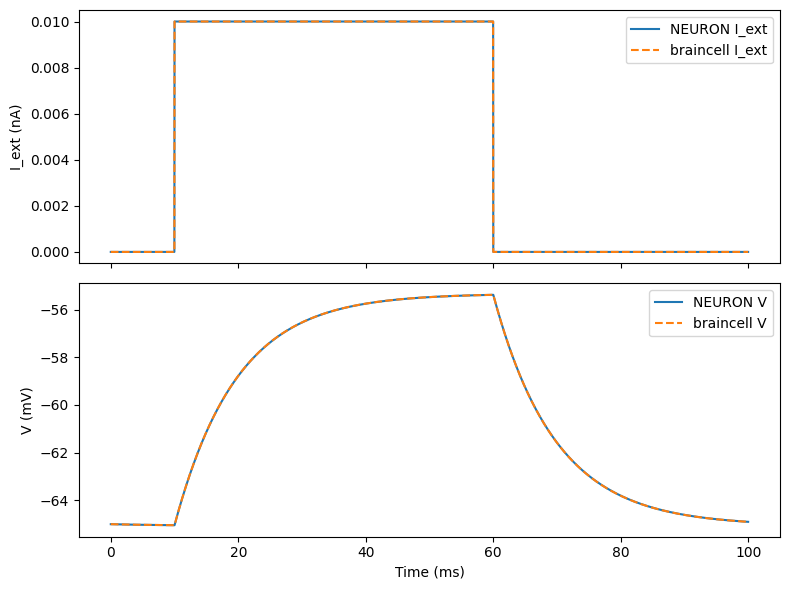

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t_neuron, i_neuron, label='NEURON I_ext')
axes[0].plot(t_braincell, i_braincell, '--', label='braincell I_ext')
axes[0].set_ylabel('I_ext (nA)')
axes[0].legend()

axes[1].plot(t_neuron, v_neuron, label='NEURON V')
axes[1].plot(t_braincell, v_braincell, '--', label='braincell V')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('V (mV)')
axes[1].legend()
fig.tight_layout()
plt.show()


### 手写方式的特点

- 最适合快速试一个 case。
- `I_ext(t_ms)` 是任意 Python 函数，最自由。
- 通道名字仍然分开写：NEURON 用 `mechanism`，braincell 用 `channel_name`。
- 这里的 `channel_spec['params']` 是共享的一组参数；如果两侧参数差异很大，后面更适合用 sweep 模板。


## 2. 第一个模板：`channel_validate.py`

这个脚本可以看成“手写方式”的最小模板版。

它的 `main()` 会：

- 构造一个单室 NEURON cell
- 构造一个单室 braincell cell
- 使用脚本内部定义的 `I_ext(t_ms)`
- 输出电压误差
- 生成 `channel_validate.png`

如果你只想快速跑一次并看图，直接运行它就够了。


In [ ]:
single.main()

figure=/home/swl/braincell/examples/convert_mod/mod_validate/channel_validate.png
n_samples=4000
mae_mV=0.001262
rmse_mV=0.001980
max_abs_mV=0.004604


如果你想改这个模板，重点看 `channel_validate.py` 里的这些块：

- `common_params`
- `ion_spec`
- `channel_spec`
- `leak_spec`
- `I_ext(t_ms)`

这个模板仍然适合单个 case，不适合系统扫很多刺激条件。


## 3. 第二个模板：`channel_validate_sweep.py`

这个脚本面向“同一个通道，在多个刺激条件下批量对比”。

和手写版最大的差别是：

- `global` 放共享基础参数
- `neuron.channel_params` 和 `braincell.channel_params` 分开写
- 刺激通过 `sweep_grid` 定义成一个网格


In [7]:
cfg = sweep.load_config(config_path)

print(json.dumps(cfg['global'], indent=2, ensure_ascii=False))
print(json.dumps(cfg['neuron'], indent=2, ensure_ascii=False))
print(json.dumps(cfg['braincell'], indent=2, ensure_ascii=False))


{
  "dt_ms": 0.025,
  "v_init_mV": -65.0,
  "temperature_celsius": 25.0,
  "L_um": 10.0,
  "diam_um": 31.830988618379067,
  "cm_uF_cm2": 1.0,
  "ion_type": "k",
  "ion_rev_mV": -80.0
}
{
  "mod_dir": "/home/swl/braincell/examples/convert_mod/mod_validate/mods",
  "mechanism": "Kv",
  "leak": {
    "g_S_cm2": 0.0001,
    "e_mV": -65.0
  },
  "channel_params": {
    "gbar_S_cm2": 0.01
  },
  "gate_var": "n"
}
{
  "solver": "rk4",
  "channel_name": "IK_Kv_test",
  "leak": {
    "g_S_cm2": 0.0001,
    "e_mV": -65.0
  },
  "channel_params": {
    "g_max_S_cm2": 0.01
  }
}


In [8]:
cases = sweep.expand_cases(cfg['sweep_grid'])
print('n_cases =', len(cases))
cases[:3]


n_cases = 14


[{'case_id': 0,
  'tstop_ms': 50.0,
  'amp_nA': 0.01,
  'delay_ms': 0.0,
  'dur_ms': 20.0},
 {'case_id': 1,
  'tstop_ms': 50.0,
  'amp_nA': 0.01,
  'delay_ms': 0.0,
  'dur_ms': 50.0},
 {'case_id': 2,
  'tstop_ms': 50.0,
  'amp_nA': 0.01,
  'delay_ms': 10.0,
  'dur_ms': 20.0}]

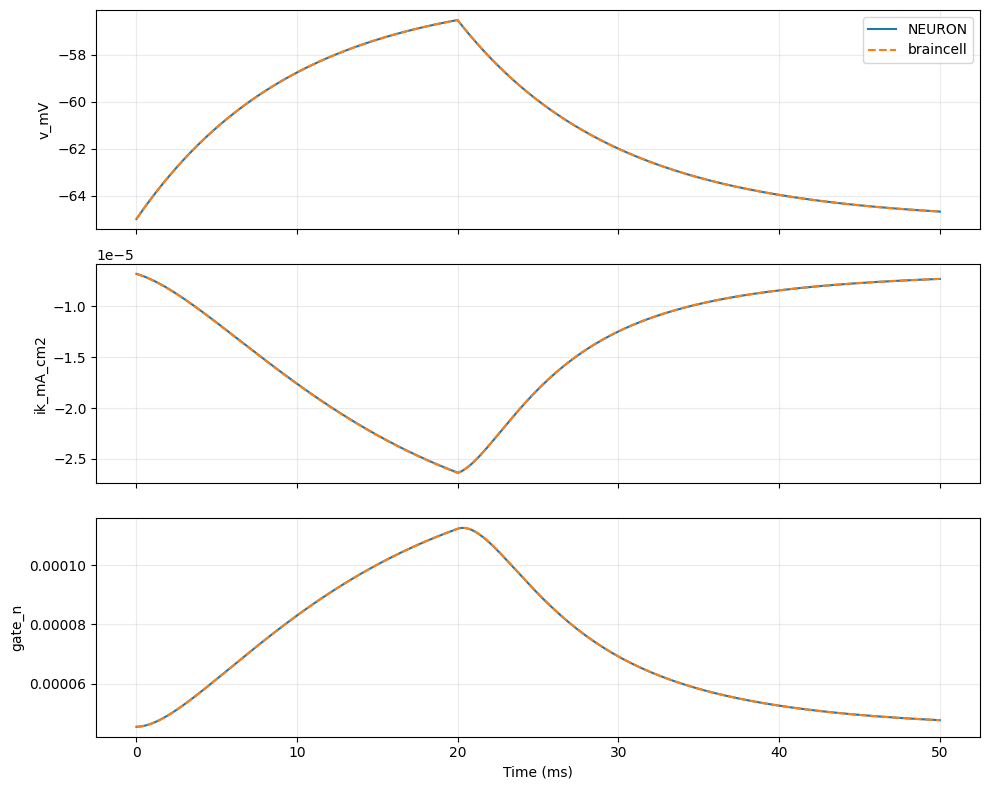

{'v_mV': {'mae': 0.0027364120695591793,
  'rmse': 0.0029559825407091244,
  'max_abs': 0.004515983224465003,
  'mean_bias': -0.00033440213490420237,
  'rel_mae_pct': 0.004518028524871227,
  'n_samples': 2000},
 'ik_mA_cm2': {'mae': 1.8098388815317915e-08,
  'rmse': 2.0419043827786694e-08,
  'max_abs': 3.014167807396432e-08,
  'mean_bias': 2.624863264439572e-09,
  'rel_mae_pct': 0.12623013983915993,
  'n_samples': 2000},
 'gate_n': {'mae': 2.195554428370865e-08,
  'rmse': 3.264657545308308e-08,
  'max_abs': 9.319041647735916e-08,
  'mean_bias': -7.684051857227001e-09,
  'rel_mae_pct': 0.028439597898942567,
  'n_samples': 2000}}

In [9]:
single_case = cases[0]
result = sweep.compare_case(cfg, single_case, cfg['metrics']['observables'])

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, obs in zip(axes, cfg['metrics']['observables']):
    ax.plot(result['time_ms'], result['neuron'][obs], label='NEURON')
    ax.plot(result['time_ms'], result['braincell'][obs], '--', label='braincell')
    ax.set_ylabel(obs)
    ax.grid(alpha=0.25)
axes[0].legend()
axes[-1].set_xlabel('Time (ms)')
fig.tight_layout()
plt.show()

result['metrics']


In [10]:
out_dir = ROOT / 'tutorial_sweep_out'
exit_code = sweep.run(cfg, out_dir=out_dir, do_plot=False)
print('exit_code =', exit_code)

aggregate = json.loads((out_dir / 'aggregate.json').read_text(encoding='utf-8'))
aggregate['overall']


Finished 14 cases: 14 success, 0 failed.
{
  "case_weighted_mean_rmse": 0.0012731976435478357,
  "case_weighted_mean_mae": 0.0010482452294331866
}
Outputs written to: /home/swl/braincell/examples/convert_mod/mod_validate/tutorial_sweep_out
exit_code = 0


{'case_weighted_mean_rmse': 0.0012731976435478357,
 'case_weighted_mean_mae': 0.0010482452294331866}

### sweep 配置的当前形状

当前推荐结构是：

- `global`：`dt_ms`、`v_init_mV`、`temperature_celsius`、`L_um`、`diam_um`、`cm_uF_cm2`、`ion_type`、`ion_rev_mV`
- `neuron`：`mod_dir`、`mechanism`、`channel_params`、`gate_var`、可选 `leak`
- `braincell`：`solver`、`channel_name`、`channel_params`、可选 `leak`

注意：通道名不做统一。NEURON 和 braincell 的名字要分别写。


## 4. 什么时候用哪一个

- 用手写方式：你还在试接口，或者想直接写任意 `I_ext(t_ms)`。
- 用 `channel_validate.py`：你只想快速跑一个最小 case。
- 用 `channel_validate_sweep.py`：你已经确定通道，准备系统扫一批刺激条件并保存统计结果。

建议工作流：先手写跑通一个 case，再整理成最小模板，最后再切到 sweep。
